In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import RANK
import linear
from aux_ import choose_gpu

### Choose device

In [3]:
device = choose_gpu()

Avaliable devices:


cuBLAS < 13.2 (120902 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


cuda:0

Device = cuda:0 is choosen


# OccBin

In [4]:
model = RANK.RANK_model(device)
nn_path = 'output/final_nn.pkl'
model.load(nn_path, opt_load=False)

In [11]:
sigma_quad = {
    "sigma_eps_u": 0.00135,
    "sigma_eps_z": 0.020814,
    "sigma_eps_Gamma": 0.012778
}

print(sigma_quad)

{'sigma_eps_u': 0.00135, 'sigma_eps_z': 0.020814, 'sigma_eps_Gamma': 0.012778}


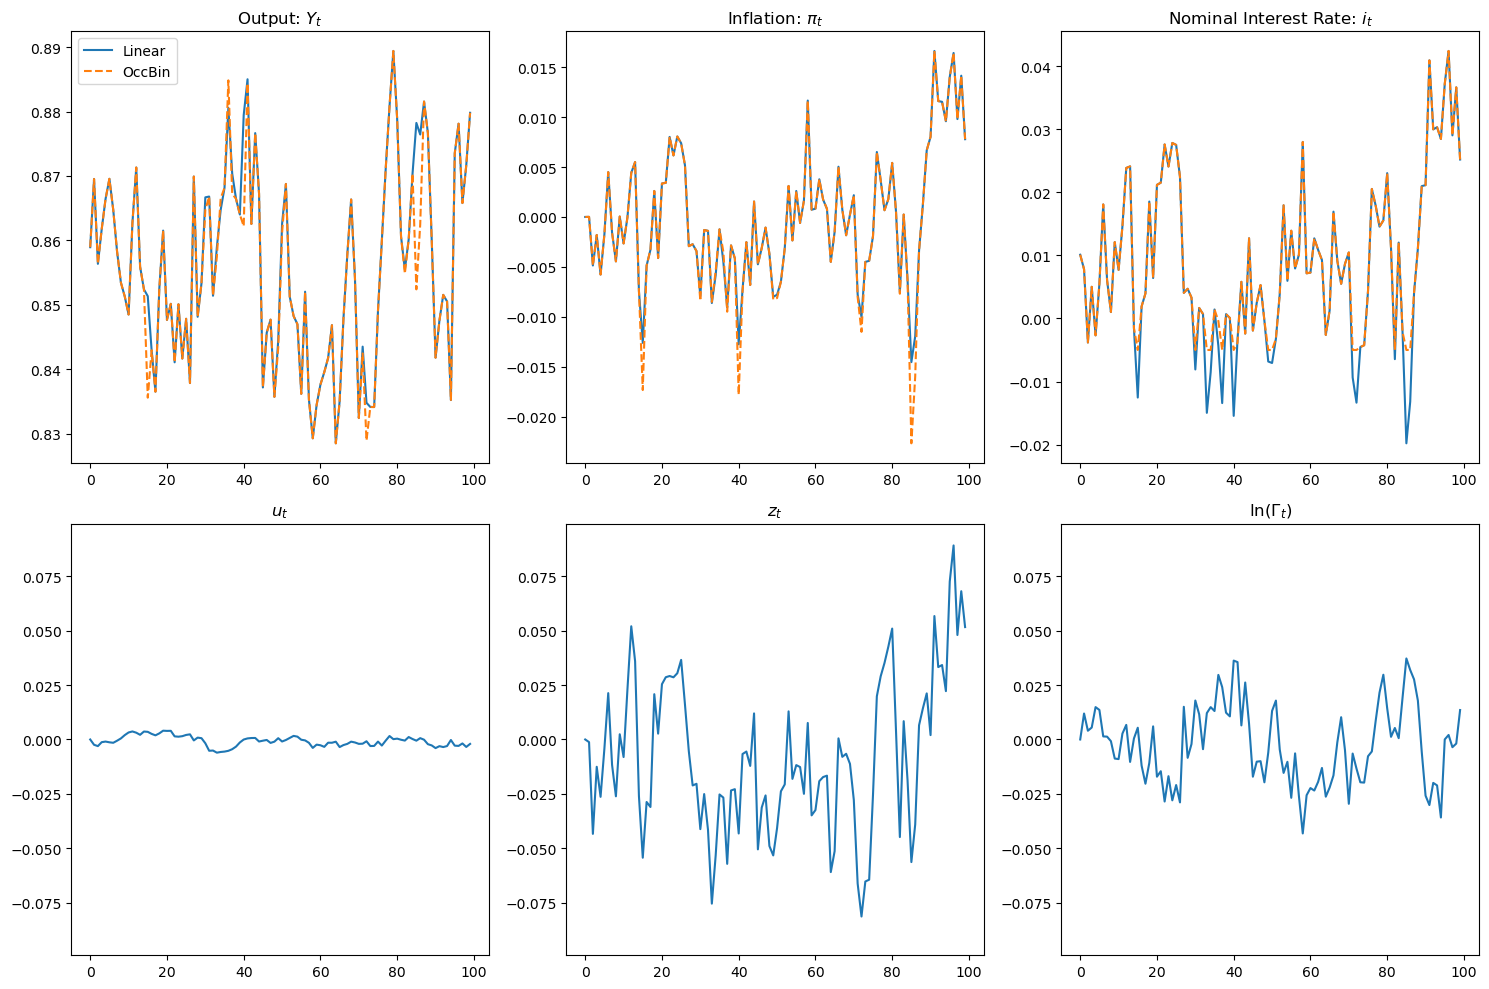

In [12]:
linear.simulate_linear(model, sigma_quad, 100, plot=True, key_=10)

# Check OccBin and log-linear with Dynare

Consider massive shocks of 10 standard-deviations to ensure solution holds even for extreme events

In [7]:
factor = 10

sigma_IRFs = {
    "sigma_eps_u": factor*0.00135,
    "sigma_eps_z": -factor*0.02160123129280831, # make z-shock negative since it sends the economy to ZLB most often
    "sigma_eps_Gamma": factor*0.01235612452009231
}

Loading MatLab Results with:
{'sigma_eps_u': 0.013500000000000002, 'sigma_eps_z': -0.2160123129280831, 'sigma_eps_Gamma': 0.12356124520092311}


{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACA64, Created on: Thu May 28 04:26:26 2026', '__version__': '1.0', '__globals__': [], 'all_linear_results': array([[[-8.54584549e-03,  8.54584549e-03,  3.78891512e-02,
         -3.78891512e-02,  9.57139521e-02, -9.57139521e-02],
        [-1.19087000e-02,  1.19087000e-02,  3.43603084e-02,
         -3.43603084e-02, -2.01459469e-02,  2.01459469e-02],
        [-8.63597269e-03,  8.63597269e-03,  7.04850382e-02,
         -7.04850382e-02, -4.41425669e-02,  4.41425669e-02],
        [-8.63597269e-03,  8.63597269e-03,  7.04850382e-02,
         -7.04850382e-02, -4.41425669e-02,  4.41425669e-02],
        [ 1.35000000e-02, -1.35000000e-02,  5.11514898e-18,
         -5.11514898e-18, -5.43484580e-18,  5.43484580e-18],
        [ 0.00000000e+00,  0.00000000e+00,  2.16012313e-01,
         -2.16012313e-01,  0.000

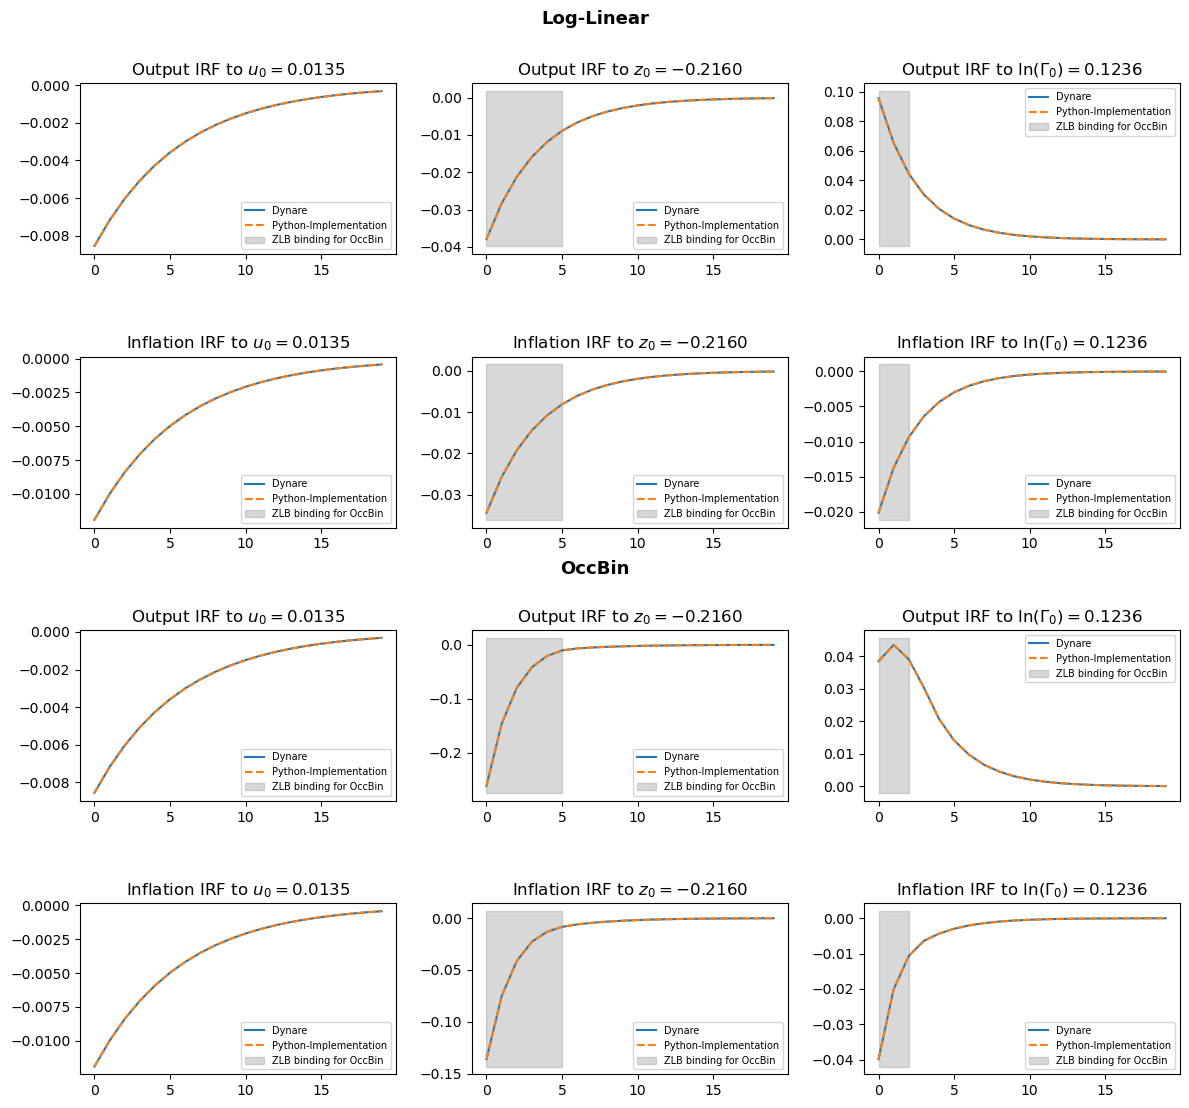

In [8]:
linear.check_dynare(model, "MatLab/all_6_shocks_results.mat", sigma_IRFs)